In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, RocCurveDisplay
from sklearn.calibration import calibration_curve

df_v1 = pd.read_parquet("data/shots_features.parquet")
df_v2 = pd.read_parquet("data/shots_features_v2.parquet")

FEATURES_V1 = ["distance", "angle", "is_header", "is_open_play"]
FEATURES_V2 = [
    "distance", "angle", "is_header", "is_open_play", "is_penalty",
    "goalkeeper_coverage", "goalkeeper_coverage_available",
    "defenders_in_lane", "defenders_in_lane_available"
]
TARGET = "is_goal"

PENALTY_PRIOR = 0.79

print(df_v1[FEATURES_V1 + [TARGET]].describe())
print(f"\nShape: {df_v1.shape}")
print(f"\nNull counts:\n{df_v1[FEATURES_V1 + [TARGET]].isnull().sum()}")

print(df_v2[FEATURES_V2 + [TARGET]].describe())
print(f"\nShape: {df_v2.shape}")
print(f"\nNull counts:\n{df_v2[FEATURES_V2 + [TARGET]].isnull().sum()}")

          distance        angle    is_header  is_open_play      is_goal
count  9168.000000  9168.000000  9168.000000   9168.000000  9168.000000
mean     19.046284    25.386265     0.163067      0.944699     0.110602
std       8.685988    15.697708     0.369447      0.228579     0.313656
min       0.632456     0.299683     0.000000      0.000000     0.000000
25%      12.000417    15.114400     0.000000      1.000000     0.000000
50%      18.261709    19.682607     0.000000      1.000000     0.000000
75%      25.269300    31.536490     0.000000      1.000000     0.000000
max      74.867416   179.999260     1.000000      1.000000     1.000000

Shape: (9168, 12)

Null counts:
distance        0
angle           0
is_header       0
is_open_play    0
is_goal         0
dtype: int64
          distance        angle    is_header  is_open_play  is_penalty  \
count  9168.000000  9168.000000  9168.000000   9168.000000  9168.00000   
mean     19.046284    25.386265     0.163067      0.944699     0.010

In [15]:
X1 = df_v1[FEATURES_V1]
X2 = df_v2[FEATURES_V2]
Y = df_v1[TARGET]

X1_train, X1_test, X2_train, X2_test, Y_train, Y_test = train_test_split(
    X1, X2, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

penalty_mask = df_v2["is_penalty"] == 1
X2_pen = df_v2.loc[penalty_mask, FEATURES_V2]
Y_pen = df_v2.loc[penalty_mask, TARGET]

print(f"Train: {X1_train.shape[0]} shots, {Y_train.sum()} goals ({Y_train.mean():.3f})")
print(f"Test:  {X1_test.shape[0]} shots, {Y_test.sum()} goals ({Y_test.mean():.3f})")

print(f"Train: {X2_train.shape[0]} shots, {Y_train.sum()} goals ({Y_train.mean():.3f})")
print(f"Test:  {X2_test.shape[0]} shots, {Y_test.sum()} goals ({Y_test.mean():.3f})")

print(f"Penalties held out for V3 inference: {len(X2_pen)} shots")

Train: 7334 shots, 811 goals (0.111)
Test:  1834 shots, 203 goals (0.111)
Train: 7334 shots, 811 goals (0.111)
Test:  1834 shots, 203 goals (0.111)
Penalties held out for V3 inference: 97 shots


In [16]:
model_v1 = LogisticRegression(max_iter=1000, random_state=42)
model_v1.fit(X1_train, Y_train)
Y_prob_v1 = model_v1.predict_proba(X1_test)[:, 1]

In [17]:
model_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
model_v2.fit(X2_train, Y_train)
Y_prob_v2 = model_v2.predict_proba(X2_test)[:, 1]

In [18]:
FEATURES_V3 = [f for f in FEATURES_V2 if f != "is_penalty"]

model_v3 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
model_v3.fit(X2_train[FEATURES_V3], Y_train)

def predict_with_penalty_prior(model, X_non_pen, X_pen, features):
    prob_non_pen = model.predict_proba(X_non_pen[features])[:, 1]
    prob_pen = np.full(len(X_pen), PENALTY_PRIOR)
    idx = list(X_non_pen.index) + list(X_pen.index)
    probs = np.concatenate([prob_non_pen, prob_pen])
    return pd.Series(probs, index=idx)

Y_prob_v3_full = predict_with_penalty_prior(
    model_v3, X2_test[FEATURES_V3], X2_pen[FEATURES_V3], FEATURES_V3
)
Y_test_full = pd.concat([Y_test, Y_pen])

In [19]:
brier_v1 = brier_score_loss(Y_test, Y_prob_v1)
brier_v2 = brier_score_loss(Y_test, Y_prob_v2)
brier_v3 = brier_score_loss(Y_test_full, Y_prob_v3_full)
auc_v1 = roc_auc_score(Y_test, Y_prob_v1)
auc_v2 = roc_auc_score(Y_test, Y_prob_v2)
auc_v3 = roc_auc_score(Y_test_full, Y_prob_v3_full)

print(f"{'':20} {'V1':>8} {'V2':>8} {'V3':>8}")
print(f"{'Brier score':20} {brier_v1:>8.4f} {brier_v2:>8.4f} {brier_v3:>8.4f}")
print(f"{'AUC':20} {auc_v1:>8.4f} {auc_v2:>8.4f} {auc_v3:>8.4f}")

print(f"\nV1 Coefficients:")
for feat, coef in zip(FEATURES_V1, model_v1.coef_[0]):
    print(f"  {feat:<30} {coef:>8.4f}")
print(f"  {'intercept':<30} {model_v1.intercept_[0]:>8.4f}")

print(f"\nV2 Coefficients:")
clf_v2 = model_v2.named_steps["classifier"]
for feat, coef in zip(FEATURES_V2, clf_v2.coef_[0]):
    print(f"  {feat:<30} {coef:>8.4f}")
print(f"  {'intercept':<30} {clf_v2.intercept_[0]:>8.4f}")

print(f"\nV3 Coefficients:")
clf_v3 = model_v3.named_steps["classifier"]
for feat, coef in zip(FEATURES_V3, clf_v3.coef_[0]):
    print(f"  {feat:<30} {coef:>8.4f}")
print(f"  {'intercept':<30} {clf_v3.intercept_[0]:>8.4f}")

                           V1       V2       V3
Brier score            0.0822   0.0795   0.0861
AUC                    0.8042   0.8202   0.8533

V1 Coefficients:
  distance                        -0.1320
  angle                            0.0233
  is_header                       -1.3465
  is_open_play                    -1.7303
  intercept                        1.1521

V2 Coefficients:
  distance                        -0.1104
  angle                            0.0238
  is_header                       -1.2423
  is_open_play                    -1.9498
  is_penalty                       0.0046
  goalkeeper_coverage              0.1466
  goalkeeper_coverage_available   -0.7408
  defenders_in_lane               -0.4014
  defenders_in_lane_available      0.5413
  intercept                        1.2986

V3 Coefficients:
  distance                        -0.1101
  angle                            0.0239
  is_header                       -1.2470
  is_open_play                    -1.9452
  go

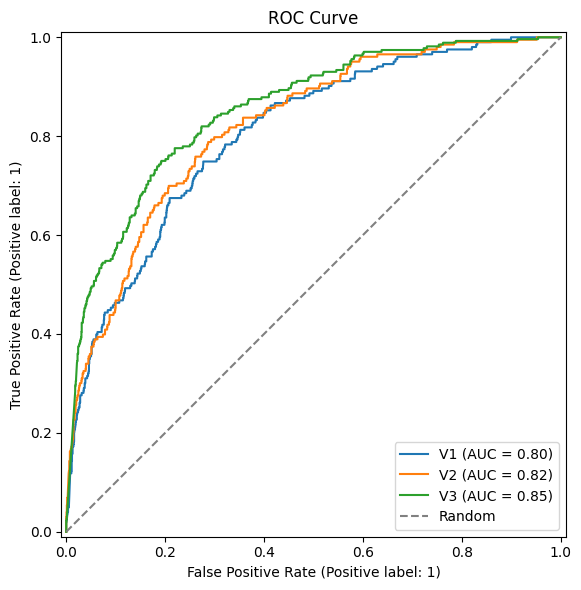

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(Y_test, Y_prob_v1, ax=ax, name="V1")
RocCurveDisplay.from_predictions(Y_test, Y_prob_v2, ax=ax, name="V2")
RocCurveDisplay.from_predictions(Y_test_full, Y_prob_v3_full, ax=ax, name="V3")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150)
plt.show()

Correlation with StatsBomb xG — V1: 0.8228  V2: 0.8725  V3: 0.9407


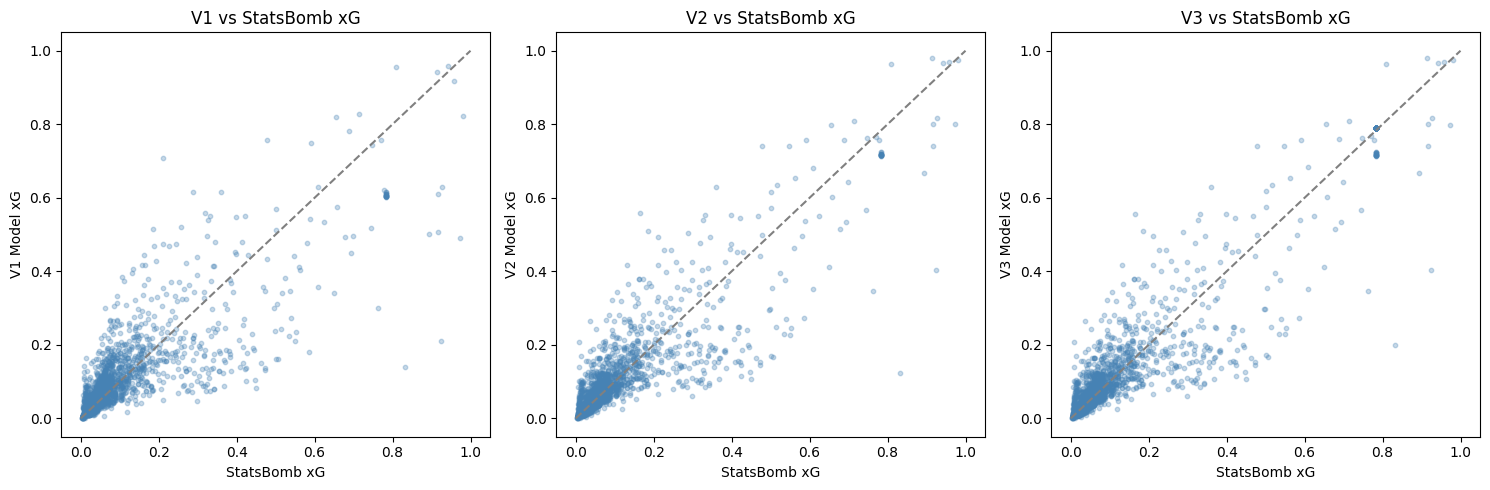

In [21]:
sb_xg_test = df_v1.loc[X1_test.index, "shot_statsbomb_xg"]
sb_xg_full = df_v1.loc[Y_test_full.index, "shot_statsbomb_xg"]

corr_v1 = np.corrcoef(sb_xg_test, Y_prob_v1)[0, 1]
corr_v2 = np.corrcoef(sb_xg_test, Y_prob_v2)[0, 1]
corr_v3 = np.corrcoef(sb_xg_full, Y_prob_v3_full)[0, 1]
print(f"Correlation with StatsBomb xG — V1: {corr_v1:.4f}  V2: {corr_v2:.4f}  V3: {corr_v3:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, y_prob, sb_xg, label in zip(
    axes,
    [Y_prob_v1, Y_prob_v2, Y_prob_v3_full],
    [sb_xg_test, sb_xg_test, sb_xg_full],
    ["V1", "V2", "V3"]
):
    ax.scatter(sb_xg, y_prob, alpha=0.3, s=10, color="steelblue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("StatsBomb xG")
    ax.set_ylabel(f"{label} Model xG")
    ax.set_title(f"{label} vs StatsBomb xG")
plt.tight_layout()
plt.savefig("outputs/xg_comparison_scatter.png", dpi=150)
plt.show()

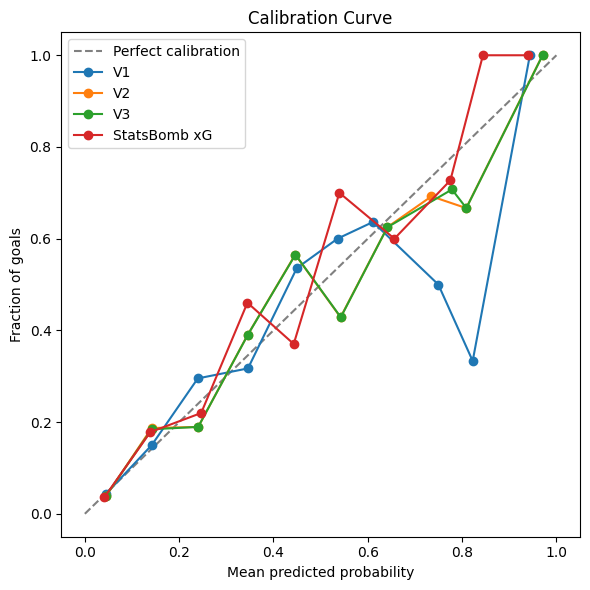

In [22]:
prob_true_v1, prob_pred_v1 = calibration_curve(Y_test, Y_prob_v1, n_bins=10)
prob_true_v2, prob_pred_v2 = calibration_curve(Y_test, Y_prob_v2, n_bins=10)
prob_true_v3, prob_pred_v3 = calibration_curve(Y_test_full, Y_prob_v3_full, n_bins=10)
prob_true_sb, prob_pred_sb = calibration_curve(Y_test, sb_xg_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(prob_pred_v1, prob_true_v1, marker="o", label="V1")
ax.plot(prob_pred_v2, prob_true_v2, marker="o", label="V2")
ax.plot(prob_pred_v3, prob_true_v3, marker="o", label="V3")
ax.plot(prob_pred_sb, prob_true_sb, marker="o", label="StatsBomb xG")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of goals")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/calibration_curve.png", dpi=150)
plt.show()

## Model Interpretation

_You can find the graphs for model comparison under the outputs directory. Each model has a ROC curve, a comparison scatter plot, and a calibration curve_

### Model V1
The V1 logistic regression model uses features such as distance, angle, is_header, is_open_play. It underestimates probability on high-quality chances (predicted >0.6), and is overconfident on shots the model assigns 0.8 xG convert at approximately 30% in reality. The StatsBomb's model
uses features unavailable in this first version of my model, and those missing features drive the difference on genuine big chances.

The negative coefficient (-1.73) for is_open_play is counterintuitive but correct,since the feature groups penalties with corners and free kicks under is_open_play = 0. Penalties convert at ~75–80% from a fixed central position; controlling for distance
and angle, the model correctly learns that non-open-play shots outperform their spatial position. A cleaner implementation would separate is_penalty as a distinct feature — this is the primary candidate for V2.

### Model V2

V2 extends V1 with three freeze-frame-derived features: `is_penalty`, `goalkeeper_coverage`, and `defenders_in_lane`, plus availability flags 
for the two continuous freeze frame features to handle missing values.

Distance retains the largest directional effect (-0.1104 per yard). The modest reduction from V1 (-0.1320) reflects the freeze frame features 
absorbing some spatial variance — once goalkeeper position and defensive crowding are known, raw distance is slightly less predictive on its own.

**goalkeeper_coverage (0.1466):** Positive coefficient, correct direction. The feature measures perpendicular distance from the goalkeeper to the shooter-to-goal-center line. A larger value means the keeper is further off the shooting lane — more poorly positioned. The model correctly learns that a displaced keeper increases goal probability.

**defenders_in_lane (-0.4014):** Negative coefficient, correct direction. Each additional outfield defender in the shot cone reduces goal probability. This is the expected effect — bodies between shooter and goal block sight lines and reduce the shooter's available target area.


The model's primary failure is that freeze frame features improve calibration on genuine big chances, but the mechanism is 
contaminated. The `goalkeeper_coverage_available` flag is doing the heaviest lifting in the high-xG range, because that flag is correlated with penalty status: When the shot type is "Penalty" the data doesn't include the freeze frame.

What does it mean? Model V2 is cheating (feature leakage). Since penalties structurally contain no freeze frame data, using imputation on null values for the second version of feature shots is distorting reality for the model.

The primary candidate for V3: exclude penalties from training entirely and assign them a fixed prior of 0.79 at inference. This would isolate the freeze frame features' actual contribution to non-penalty shot quality and eliminate the availability flag leakage at its source.

### Model V3

Removing penalties from training and assigning them a fixed 0.79 xG collapses the availability flag coefficients to near-zero, confirmation that V2's large flag coefficients were absorbing penalty conversion rates.

`is_open_play` stays negative with penalties gone. What remains under `is_open_play` = 0 is corners and free kicks — and those do outperform their spatial position, so the coefficient is correct. The feature is just underspecified: open play, free kicks, and corners are three different shot contexts I collapsed into one binary.